# **ANÁLISIS DE GRANDES VOLÚMENES DE DATOS**

## **Aprendizaje supervisado y no supervisado**

* A01796933 - Jose Luis Armenta Mandujano   


Codigo Anterior.

* **Alcance Local o Global:**  Artistas presentes en mas de 10 paises, se catalogan como Globales.
* **Artista Nuevo o Veterano:**  Artistas con mas de 365 días en el chart, se definen como veteranos.
* **Desempeño (Top o Estable):** Artistas en los primeros 50 lugares en el país, se consideran Top.

## **Inicialización**

In [1]:
import findspark
findspark.init()
findspark.find()

'C:\\Users\\JLAM\\anaconda\\envs\\pyspark-sara\\Lib\\site-packages\\pyspark'

In [2]:
import os
import sys
import findspark

from pyspark.sql import SparkSession
import pyspark.sql.functions as F

spark = SparkSession.builder \
    .appName("Spotify_BigData_Analysis") \
    .config("spark.driver.memory", "16g") \
    .getOrCreate()

# Verificación rápida de que el motor encendió
print("Sesión de Spark lista")
spark

Sesión de Spark lista


In [3]:
import os

# Define a new temporary directory for Spark
spark_local_dir = os.path.join(os.getcwd(), "spark_tmp")

# Create the directory if it doesn't exist
if not os.path.exists(spark_local_dir):
    os.makedirs(spark_local_dir)
    print(f"Created Spark local directory: {spark_local_dir}")
else:
    print(f"Spark local directory already exists: {spark_local_dir}")

# Stop the existing Spark session if it's running to apply new configurations
if 'spark' in globals() and spark.sparkContext._jsc is not None:
    print("Stopping existing Spark session...")
    spark.stop()
    print("Spark session stopped.")

# Recreate the Spark session with the new local directory configuration
spark = SparkSession.builder \
    .appName("Spotify_BigData_Analysis") \
    .config("spark.driver.memory", "16g") \
      .config("spark.executor.memory", "8g") \
    .config("spark.executor.cores", "4") \
    .config("spark.driver.maxResultSize", "4g") \
    .config("spark.local.dir", spark_local_dir) \
    .getOrCreate()

print("Spark session restarted with new `spark.local.dir` configuration.")
spark

Spark local directory already exists: C:\Users\JLAM\Downloads\spark_tmp
Stopping existing Spark session...
Spark session stopped.
Spark session restarted with new `spark.local.dir` configuration.


In [4]:
!pip install matplotlib
!pip install seaborn

In [5]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11



In [6]:
#Se define la ruta de la base
file_path = r"C:\Users\JLAM\Downloads\charts_artists_daily.CSV"

In [7]:
# Revisando si Spark puede ver el archivo CSV, debe aparecere el tamaño del archivo mayor a 1Gb
print(os.path.exists(file_path))
print(os.path.getsize(file_path) / (1024**3), "GB")

True
2.5732853515073657 GB


## **Carga de la Base y Revisión inicial de los datos**

In [8]:
#Funciones Auxiliares

def entero_seguro(nombre_columna: str):
    return F.when(
        F.col(nombre_columna).cast('string').rlike(r'^-?\d+$'),
        F.col(nombre_columna).cast('int')
    )


def fecha_segura(nombre_columna: str):
    return F.when(
        F.col(nombre_columna).cast('string').rlike(r'^\d{4}-\d{2}-\d{2}$'),
        F.to_date(F.col(nombre_columna))
    )


def banda_rank(columna_rank: str):
    return (
        F.when(F.col(columna_rank) <= 10, '1-10')
        .when(F.col(columna_rank) <= 25, '11-25')
        .when(F.col(columna_rank) <= 50, '26-50')
        .when(F.col(columna_rank) <= 100, '51-100')
        .otherwise('101-200')
    )


ORDEN_BANDAS = ['1-10', '11-25', '26-50', '51-100', '101-200']
ORDEN_LAG = ['0-7', '8-30', '31-180', '181-365', '366-3650']

In [9]:
ruta_artistas = file_path

chart_artistas = (
    spark.read.option('header', True).csv(str(ruta_artistas))
    .select(
        fecha_segura('date').alias('fecha'),
        F.col('country').alias('pais'),
        entero_seguro('rank').alias('rank'),
        F.col('uri').alias('artist_uri'),
        F.col('artist_name').alias('artist_name'),
        entero_seguro('peak_rank').alias('peak_rank'),
        entero_seguro('previous_rank').alias('previous_rank'),
        entero_seguro('days_on_chart').alias('days_on_chart'),
        entero_seguro('consecutive_days').alias('consecutive_days'),
        F.col('entry_status').alias('entry_status'),
        entero_seguro('entry_rank').alias('entry_rank'),
        fecha_segura('entry_date').alias('entry_date')
    )
)

In [10]:
#Validación del tipo de datos
chart_artistas.dtypes

[('fecha', 'date'),
 ('pais', 'string'),
 ('rank', 'int'),
 ('artist_uri', 'string'),
 ('artist_name', 'string'),
 ('peak_rank', 'int'),
 ('previous_rank', 'int'),
 ('days_on_chart', 'int'),
 ('consecutive_days', 'int'),
 ('entry_status', 'string'),
 ('entry_rank', 'int'),
 ('entry_date', 'date')]

In [11]:
resumen_spark = chart_artistas.select(
    F.lit("Artistas diarios").alias("dataset"),
    F.count("*").alias("filas"),
    F.countDistinct("pais").alias("paises"),
    F.countDistinct("artist_name").alias("artistas_distintos"),
    F.countDistinct("artist_uri").alias("artistas_distintos_uri"),
    F.min("fecha").alias("fecha_min"),
    F.max("fecha").alias("fecha_max")
)

resumen_cobertura = resumen_spark.toPandas()

display(resumen_cobertura)

,dataset,filas,paises,artistas_distintos,artistas_distintos_uri,fecha_min,fecha_max
0,Artistas diarios,22683298,71,22799,23136,2021-10-21,2026-04-30


In [12]:
resumen_calidad_spark = chart_artistas.select(
    F.lit("artistas").alias("tabla"),
    F.sum(F.when(F.col("rank").isNull(), 1).otherwise(0)).alias("filas_rank_invalido"),
    F.sum(F.when(F.col("fecha").isNull(), 1).otherwise(0)).alias("filas_fecha_invalida"),
    F.sum(F.when(F.col("days_on_chart").isNull(), 1).otherwise(0)).alias("filas_days_on_chart_invalido"),
    F.sum(F.when(F.col("artist_name").isNull() | (F.col("artist_name") == ""), 1).otherwise(0)).alias("filas_nombre_artista_invalido")
)

resumen_calidad = resumen_calidad_spark.toPandas()

display(resumen_calidad)

,tabla,filas_rank_invalido,filas_fecha_invalida,filas_days_on_chart_invalido,filas_nombre_artista_invalido
0,artistas,0,0,0,0


## **Analisis de información**

### Insight 1: concentracion del liderazgo en el puesto #1

In [13]:
top_no1 = (
    chart_artistas.where(F.col('rank') == 1)
    .groupBy('artist_name')
    .agg(
        F.count('*').alias('dias_pais_en_no1'),
        F.countDistinct('pais').alias('paises_con_no1')
    )
    .orderBy(F.desc('dias_pais_en_no1'))
    .toPandas()
)

# top_no1.head(15)

In [14]:
if not top_no1.empty:
    total_no1 = top_no1['dias_pais_en_no1'].sum()
    share_top10 = top_no1.head(10)['dias_pais_en_no1'].sum() / total_no1
    lider = top_no1.iloc[0]
    print(f"Los 10 artistas con mas dias-pais en el puesto #1 concentran el {share_top10:.1%} de todos los liderazgos del dataset.")
    print(f"El artista mas dominante es {lider['artist_name']} con {int(lider['dias_pais_en_no1']):,} dias-pais en #1 y presencia de liderazgo en {int(lider['paises_con_no1'])} paises.")

#    plt.figure(figsize=(14, 8))
#    sns.barplot(data=top_no1.head(20), x='dias_pais_en_no1', y='artist_name', palette='rocket')
#    plt.title('Artistas con mayor dominancia acumulada en el puesto #1')
#    plt.xlabel('Dias-pais en el puesto #1')
#   plt.ylabel('Artista')
#    plt.tight_layout()
#    plt.show()


Los 10 artistas con mas dias-pais en el puesto #1 concentran el 53.3% de todos los liderazgos del dataset.
El artista mas dominante es Bad Bunny con 25,636 dias-pais en #1 y presencia de liderazgo en 40 paises.


### Insight 2: alcance global vs dominancia local

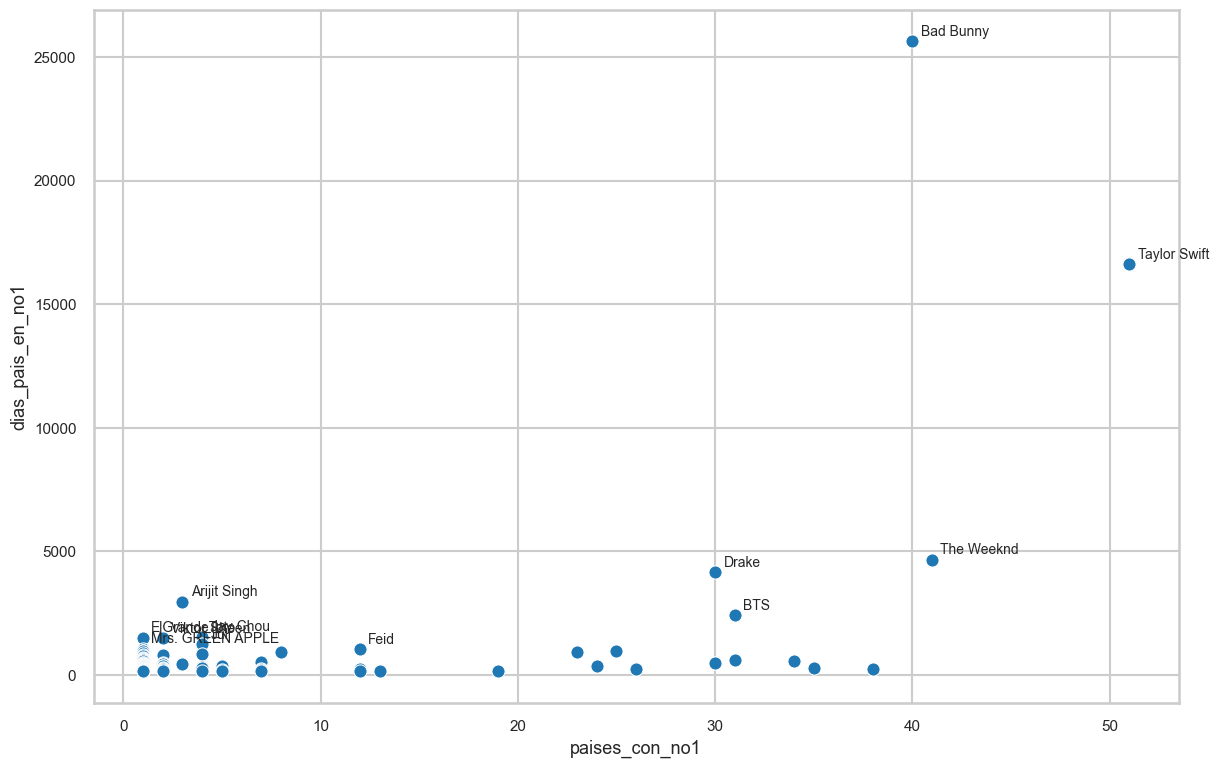

In [15]:
if not top_no1.empty:
    pdf_alcance = top_no1[top_no1['dias_pais_en_no1'] >= 150].copy()
    destacar = pdf_alcance.sort_values(['dias_pais_en_no1', 'paises_con_no1'], ascending=[False, False]).head(12)

    plt.figure(figsize=(14, 9))
    sns.scatterplot(
        data=pdf_alcance,
        x='paises_con_no1',
        y='dias_pais_en_no1',
        s=90,
        color='#1f78b4'
    )
    for _, fila in destacar.iterrows():
        plt.annotate(fila['artist_name'], (fila['paises_con_no1'], fila['dias_pais_en_no1']), xytext=(6, 4), textcoords='offset points', fontsize=10)

#    plt.title('Artistas: expansion geografica del liderazgo vs intensidad de dominancia')
#    plt.xlabel('Paises donde alcanzaron el puesto #1')
#    plt.ylabel('Dias-pais acumulados en el puesto #1')
#    plt.tight_layout()
#    plt.show()

    locales = pdf_alcance[pdf_alcance['paises_con_no1'] <= 3].sort_values('dias_pais_en_no1', ascending=False).head(5)
    globales = pdf_alcance[pdf_alcance['paises_con_no1'] >= 20].sort_values('dias_pais_en_no1', ascending=False).head(5)
#    print('Lideres mas claramente locales:')
#    display(locales)
#    print('Lideres mas claramente globales:')
#    display(globales)


### Insight 3: estabilidad y recambio del Top 50 de artistas

In [16]:
#Se define la fecha de corte para no considerar los datos del primer día y sesgar las nuevas entradas.

fecha_corte = "2021-10-21"

artistas_top50_diario = (
    chart_artistas
    .where((F.col('rank') <= 50) & (F.col('fecha') > fecha_corte))
    .groupBy('fecha') # Agrupamos por día
    .agg(
        # Sumamos todos los casos y dividimos entre el total de filas de ese día
        (F.sum(F.when(F.col('entry_status') == 'NEW_ENTRY', 1).otherwise(0)) / F.count('*')).alias('share_new_entry'),
        (F.sum(F.when(F.col('entry_status') == 'RE_ENTRY', 1).otherwise(0)) / F.count('*')).alias('share_re_entry'),
        (F.sum(F.when(F.col('entry_status') == 'NO_CHANGE', 1).otherwise(0)) / F.count('*')).alias('share_no_change'),
        (F.sum(F.when(F.col('entry_status').isin('MOVED_UP', 'MOVED_DOWN'), 1).otherwise(0)) / F.count('*')).alias('share_movement')
    )
    .orderBy('fecha')
    .toPandas()
)

# Convertimos los shares a porcentajes (opcional, para lectura humana)
cols_share = [c for c in artistas_top50_diario.columns if 'share' in c]
artistas_top50_diario[cols_share] = artistas_top50_diario[cols_share] * 100

artistas_top50_diario.head()

,fecha,share_new_entry,share_re_entry,share_no_change,share_movement
0,2021-10-22,0.838826,0.000000,21.360096,77.801078
1,2021-10-23,0.060024,0.000000,26.350540,73.589436
2,2021-10-24,0.030120,0.000000,30.512048,69.457831
3,2021-10-25,0.000000,0.300481,25.000000,74.699519
4,2021-10-26,0.030030,0.090090,40.450450,59.429429


In [17]:
if not artistas_top50_diario.empty:
    if artistas_top50_diario['share_no_change'].max() > 1.0:
        cols = ['share_new_entry', 'share_re_entry', 'share_no_change', 'share_movement']
        artistas_top50_diario[cols] = artistas_top50_diario[cols] / 100

    # Métricas
    artistas_top50_diario['share_ingresos'] = artistas_top50_diario['share_new_entry'] + artistas_top50_diario['share_re_entry']
    promedio_ingresos = artistas_top50_diario['share_ingresos'].mean()
    promedio_no_change = artistas_top50_diario['share_no_change'].mean()
    pico = artistas_top50_diario.loc[artistas_top50_diario['share_ingresos'].idxmax()]

    print(f"En promedio, el {promedio_ingresos:.2%} del Top 50 corresponde a ingresos/reingresos.")
    print(f"En promedio, el {promedio_no_change:.2%} del Top 50 permanece sin cambios.")
    print(f"Pico de recambio: {pico['fecha']} con {pico['share_ingresos']:.2%}")

 #   plt.figure(figsize=(16, 7))
 #   plt.plot(artistas_top50_diario['fecha'], artistas_top50_diario['share_no_change'], label='Sin cambio')
 #   plt.plot(artistas_top50_diario['fecha'], artistas_top50_diario['share_movement'], label='Sube o baja')
 #   plt.plot(artistas_top50_diario['fecha'], artistas_top50_diario['share_ingresos'], label='Nuevas entradas/reingresos')

    # 1. Forzar el eje Y de 0 a 1.1 (110%) para dar aire arriba para la leyenda
 #   plt.ylim(0, 1.1)

    # 2. Formateador de porcentaje (1.0 = 100%)
 #   plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))

    # 3. Definir marcas cada 10% para mayor claridad técnica
 #   plt.yticks([i/10 for i in range(12)])

    # 4. Ubicar la leyenda específicamente arriba a la derecha
 #   plt.legend(loc='upper right', fontsize='small', frameon=True, shadow=True)

 #   plt.title('Composicion del Top 50 de artistas: continuidad vs recambio')
 #   plt.xlabel('Fecha')
 #   plt.ylabel('Participacion dentro del Top 50')
 #   plt.tight_layout()
 #   plt.show()


En promedio, el 1.55% del Top 50 corresponde a ingresos/reingresos.
En promedio, el 29.85% del Top 50 permanece sin cambios.
Pico de recambio: 2022-02-20 con 4.33%


### Insight 4: permanencia en chart segun banda de posicion

In [18]:
permanencia_por_banda = (
    chart_artistas.where(F.col('rank').isNotNull() & F.col('days_on_chart').isNotNull())
    .withColumn('banda_rank', banda_rank('rank'))
    .groupBy('banda_rank')
    .agg(
        F.percentile_approx('days_on_chart', 0.5, 1000).alias('mediana_dias_en_chart'),
        F.percentile_approx('consecutive_days', 0.5, 1000).alias('mediana_dias_consecutivos'),
        F.avg(F.when(F.col('entry_status') == 'NEW_ENTRY', 1).otherwise(0)).alias('share_new_entry')
    )
    .toPandas()
)

if not permanencia_por_banda.empty:
    permanencia_por_banda['orden'] = permanencia_por_banda['banda_rank'].map({b: i for i, b in enumerate(ORDEN_BANDAS)})
    permanencia_por_banda = permanencia_por_banda.sort_values('orden')
    permanencia_por_banda

La mediana de permanencia en la banda 1-10 es de 681 dias, frente a 377 dias en la banda 101-200.


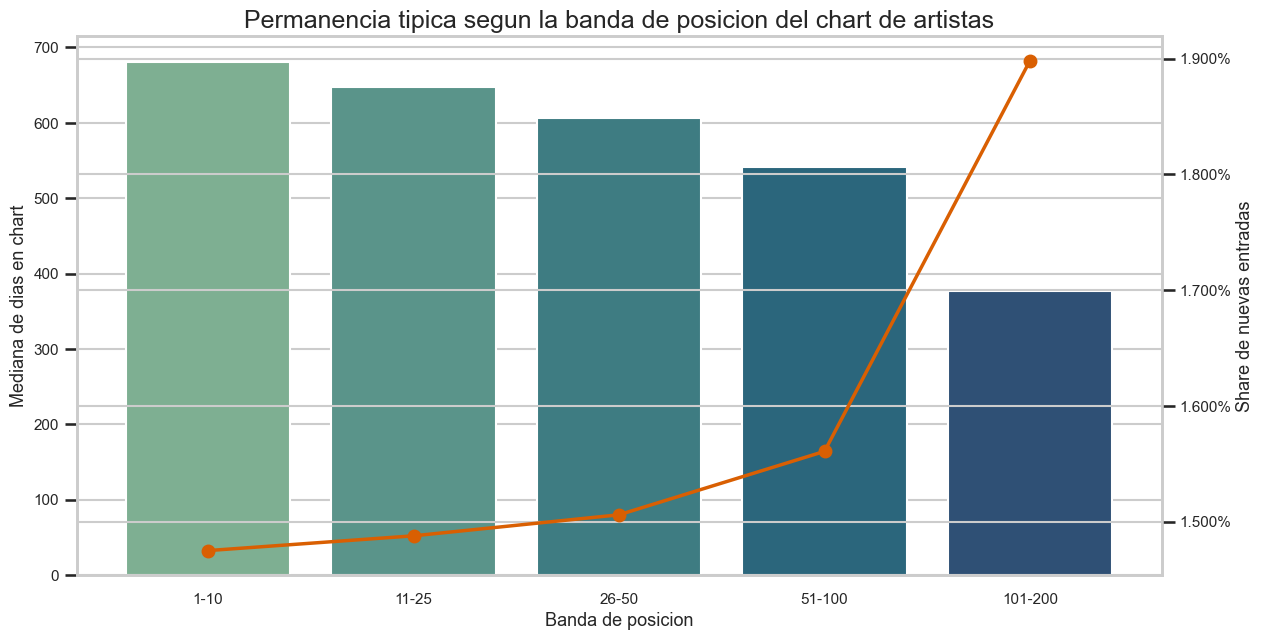

In [19]:
if not permanencia_por_banda.empty:
    fig, ax1 = plt.subplots(figsize=(14, 7))
    sns.barplot(data=permanencia_por_banda, x='banda_rank', y='mediana_dias_en_chart', palette='crest', ax=ax1)
    ax1.set_title('Permanencia tipica segun la banda de posicion del chart de artistas')
    ax1.set_xlabel('Banda de posicion')
    ax1.set_ylabel('Mediana de dias en chart')

    ax2 = ax1.twinx()
    ax2.plot(permanencia_por_banda['banda_rank'], permanencia_por_banda['share_new_entry'], color='#d95f02', marker='o', linewidth=2.5)
    ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax2.set_ylabel('Share de nuevas entradas')

 #   plt.tight_layout()
 #   plt.show()

    top10 = permanencia_por_banda.loc[permanencia_por_banda['banda_rank'] == '1-10', 'mediana_dias_en_chart'].iloc[0]
    bottom = permanencia_por_banda.loc[permanencia_por_banda['banda_rank'] == '101-200', 'mediana_dias_en_chart'].iloc[0]
    print(f"La mediana de permanencia en la banda 1-10 es de {int(top10)} dias, frente a {int(bottom)} dias en la banda 101-200.")


### Insight 5: diversidad de lideres diarios en el puesto #1

In [20]:
diversidad_no1 = (
    chart_artistas.where(F.col('rank') == 1)
    .groupBy('fecha')
    .agg(F.countDistinct('artist_name').alias('artistas_distintos_en_no1'))
    .orderBy('fecha')
    .toPandas()
)

if not diversidad_no1.empty:
    diversidad_no1['promedio_30d'] = diversidad_no1['artistas_distintos_en_no1'].rolling(30, min_periods=1).mean()
    diversidad_no1.head()


In [21]:
if not diversidad_no1.empty:
    minimo = diversidad_no1['artistas_distintos_en_no1'].min()
    maximo = diversidad_no1['artistas_distintos_en_no1'].max()
    promedio = diversidad_no1['artistas_distintos_en_no1'].mean()
    print(f"En un dia tipico, el puesto #1 es ocupado por {promedio:.1f} artistas distintos al sumar todos los paises.")
    print(f"El minimo observado fue {int(minimo)} y el maximo {int(maximo)} artistas distintos liderando simultaneamente.")

#    plt.figure(figsize=(16, 7))
#    plt.plot(diversidad_no1['fecha'], diversidad_no1['artistas_distintos_en_no1'], alpha=0.35, linewidth=1.2, label='Valor diario')
#    plt.plot(diversidad_no1['fecha'], diversidad_no1['promedio_30d'], linewidth=2.8, label='Promedio movil de 30 dias')
#    plt.title('Diversidad de artistas que lideran el puesto #1 en el mismo dia')
#    plt.xlabel('Fecha')
#    plt.ylabel('Numero de artistas distintos en #1')
#    plt.legend()
#    plt.tight_layout()
#    plt.show()

En un dia tipico, el puesto #1 es ocupado por 36.3 artistas distintos al sumar todos los paises.
El minimo observado fue 15 y el maximo 50 artistas distintos liderando simultaneamente.


### Insight 6: mercados mas estables y mas volatiles en el Top 10 de artistas

In [22]:
from pyspark.sql import functions as F

# Agregación para todos los diagnósticos
diagnostico_base = (
    chart_artistas.where(F.col('rank') <= 10)
    .groupBy('pais')
    .agg(
        F.count('*').alias('observaciones_top10'),
        F.countDistinct('fecha').alias('dias_cubiertos'),
        (F.sum(F.when(F.col('entry_status') == 'NEW_ENTRY', 1).otherwise(0)) / F.count('*')).alias('share_new_entry_top10'),
        (F.sum(F.when(F.col('entry_status') == 'NO_CHANGE', 1).otherwise(0)) / F.count('*')).alias('share_no_change_top10'),
        F.percentile_approx('days_on_chart', 0.5, 1000).alias('mediana_days_on_chart')
    )
    .where(F.col('observaciones_top10') >= 1000)
    .cache() # Cacheamos este resultado para los filtros siguientes
)

condicion_anomala = (
    (F.col('share_new_entry_top10') >= 0.90) |
    ((F.col('share_no_change_top10') == 0) & (F.col('mediana_days_on_chart') <= 1))
)

mercados_anomalos = (
    diagnostico_base
    .where(condicion_anomala)
    .orderBy('pais')
    .toPandas()
)

volatilidad_por_pais = (
    diagnostico_base
    .where(~condicion_anomala) # NOT (~) para obtener los mercados sanos
    .orderBy(F.desc('share_new_entry_top10'))
    .toPandas()
)

diagnostico_base.unpersist()

if not mercados_anomalos.empty:
    print('Mercados excluidos por patrón anómalo:')
    display(mercados_anomalos)

print('\nTop 15 Mercados por Volatilidad (Sanos):')
display(volatilidad_por_pais.head(15))

Mercados excluidos por patrón anómalo:


,pais,observaciones_top10,dias_cubiertos,share_new_entry_top10,share_no_change_top10,mediana_days_on_chart
0,ve,16190,1619,1.0,0.0,1



Top 15 Mercados por Volatilidad (Sanos):


,pais,observaciones_top10,dias_cubiertos,share_new_entry_top10,share_no_change_top10,mediana_days_on_chart
0,lu,16530,1653,0.004719,0.422263,613
1,th,16530,1653,0.001694,0.565215,626
2,is,16530,1653,0.001633,0.503085,690
3,vn,16530,1653,0.001512,0.576104,573
4,ee,16530,1653,0.001452,0.515547,687
5,sa,16530,1653,0.001210,0.607260,725
6,kr,16530,1653,0.001089,0.634967,558
7,cz,16530,1653,0.001089,0.624198,798
8,ae,16530,1653,0.001028,0.652995,745
9,ch,16530,1653,0.001028,0.474108,774


In [23]:
if not volatilidad_por_pais.empty:
    top_volatiles = volatilidad_por_pais.head(15).copy()
#    plt.figure(figsize=(14, 8))
#    sns.barplot(data=top_volatiles, x='share_new_entry_top10', y='pais', palette='magma')
#    plt.gca().xaxis.set_major_formatter(PercentFormatter(1.0))
#    plt.title('Mercados con mayor recambio de nuevas entradas en el Top 10 de artistas')
#    plt.xlabel('Share de nuevas entradas dentro del Top 10')
#    plt.ylabel('Pais')
#    plt.tight_layout()
#    plt.show()

#    print('Nota metodologica: se excluyeron mercados con patron claramente anomalo, por ejemplo aquellos donde casi el 100% del Top 10 aparece como NEW_ENTRY todos los dias.')

    top_estables = volatilidad_por_pais.sort_values('share_no_change_top10', ascending=False).head(10)
#    print('Mercados mas estables segun el share de posiciones sin cambio en el Top 10:')
#    display(top_estables[['pais', 'share_no_change_top10', 'share_new_entry_top10', 'observaciones_top10', 'dias_cubiertos', 'mediana_days_on_chart']])

#    print('Mercados mas volatiles despues de limpiar anomalias:')
#    display(top_volatiles[['pais', 'share_new_entry_top10', 'share_no_change_top10', 'observaciones_top10', 'dias_cubiertos', 'mediana_days_on_chart']])


## **Estadistica de los Datos**

In [24]:
# Filtro del mercado anomalo (Venezuela)
chart_artistas_clean = chart_artistas.where(F.col('pais') != 've').cache()

print(f"Registros después de limpieza: {chart_artistas_clean.count():,}")

Registros después de limpieza: 22,359,589


In [25]:
# Estadísticas descriptivas usando el DF limpio

#Estadisticas de Permanencia en el Chart

stats_permanencia = chart_artistas_clean.agg(
    F.min("days_on_chart").alias("min"),
    F.avg("days_on_chart").alias("media"),
    F.percentile_approx("days_on_chart", 0.5).alias("mediana"),
    F.stddev("days_on_chart").alias("DE"),
    F.percentile_approx("days_on_chart", 0.9).alias("p90"),
    F.max("days_on_chart").alias("max"),
    (F.count(F.when(F.col("days_on_chart") > 365, 1)) / F.count("*") * 100).alias("pct_supera_365")
)
stats_permanencia.show()

+---+----------------+-------+------------------+----+----+-----------------+
|min|           media|mediana|                DE| p90| max|   pct_supera_365|
+---+----------------+-------+------------------+----+----+-----------------+
|  1|588.597674536862|    491|457.49199362626666|1298|1653|59.16432542655413|
+---+----------------+-------+------------------+----+----+-----------------+



In [26]:
#Estadisticas de Globalidad

presencia_paises = chart_artistas_clean.groupBy("artist_name").agg(F.countDistinct("pais").alias("num_paises"))

stats_globalidad = presencia_paises.agg(
    F.avg("num_paises").alias("media"),
    F.percentile_approx("num_paises", 0.5).alias("mediana"),
    F.stddev("num_paises").alias("DE"),
    F.percentile_approx("num_paises", 0.9).alias("p90"),
    F.percentile_approx("num_paises", 0.95).alias("p95"),
    F.max("num_paises").alias("max"),
    (F.count(F.when(F.col("num_paises") > 10, 1)) / F.count("*") * 100).alias("pct_mas_10_paises")
)
stats_globalidad.show()

+------------------+-------+-----------------+---+---+---+------------------+
|             media|mediana|               DE|p90|p95|max| pct_mas_10_paises|
+------------------+-------+-----------------+---+---+---+------------------+
|2.7944118813626546|      1|7.004632136794786|  4|  9| 70|4.5612798025648935|
+------------------+-------+-----------------+---+---+---+------------------+



In [27]:
#Estadisticas de Ranking

stats_ranking = chart_artistas_clean.agg(
    F.min("rank").alias("min"),
    F.avg("rank").alias("media"),
    F.percentile_approx("rank", 0.5).alias("mediana"),
    F.stddev("rank").alias("DE"),
    F.max("rank").alias("max"),
    (F.count(F.when(F.col("rank") <= 50, 1)) / F.count("*") * 100).alias("pct_1_50"),
    (F.count(F.when(F.col("rank") > 50, 1)) / F.count("*") * 100).alias("pct_51_200")
)
stats_ranking.show()

+---+-----------------+-------+-----------------+---+------------------+-----------------+
|min|            media|mediana|               DE|max|          pct_1_50|       pct_51_200|
+---+-----------------+-------+-----------------+---+------------------+-----------------+
|  1|99.03028020774443|     98|57.62379224780415|200|25.739395299260643|74.26060470073935|
+---+-----------------+-------+-----------------+---+------------------+-----------------+



## **Parametros para realizar la Partición**

Los parametros de partición que se definieron son los siguientes:

* **Alcance Local o Global:**  Para este parametro se tomaran las columnas *artist_name*, *country* y *date* y se realizará un conteo diario de los paises en los que esta presente el artista.  Si el artista esta presente en mas de 10 paises, se catalogara como Global.
* **Artista Nuevo o Veterano:**  Para este parametro se tomaran las columnas *artist_name*, *days_on_chart* y *date*.  Si el artista tiene mas de 365 días en el chart, se define como veterano.
* **Desempeño (Top o Estable):** Para este parametro se tomaran las columnas *artist_name*, *country*, *rank* y *date*.  Si el artista esta entre los primeros 50 lugares en el país, es considerado Top, de lo contrario Estable.

In [28]:
chart_artistas_clean.groupBy('artist_name').count().orderBy('count', ascending=False).show(10)

+---------------+------+
|    artist_name| count|
+---------------+------+
|     The Weeknd|115256|
|   Taylor Swift|114935|
|  Billie Eilish|113308|
|  Ariana Grande|112959|
|  Justin Bieber|110716|
|       Dua Lipa|107933|
|          Drake|107881|
|   Lana Del Rey|106708|
|       Coldplay|106443|
|Imagine Dragons|104128|
+---------------+------+
only showing top 10 rows



In [29]:

chart_artistas_clean.agg(F.min('fecha').alias('min_date'), F.max('fecha').alias('max_date')).show()

+----------+----------+
|  min_date|  max_date|
+----------+----------+
|2021-10-21|2026-04-30|
+----------+----------+



In [30]:
chart_artistas_clean.groupBy('entry_status').count().orderBy('count', ascending=False).show()

+------------+-------+
|entry_status|  count|
+------------+-------+
|  MOVED_DOWN|9834069|
|    MOVED_UP|8909789|
|   NO_CHANGE|2854726|
|    RE_ENTRY| 697140|
|   NEW_ENTRY|  63865|
+------------+-------+



**Definición de Local o Global**

In [31]:
# Contar la presencia de países por artista y día

df_counts = chart_artistas_clean.groupBy("fecha", "artist_name").agg(
    F.count("pais").alias("total_countries"),
    F.max(F.when(F.col("pais") == "global", 1).otherwise(0)).alias("in_global_chart")
)

# Unir esta información con el DataFrame original (D)
df_with_scope = chart_artistas_clean.join(df_counts, ["fecha", "artist_name"], "left")

In [32]:
# Crear la columna de caracterización 'Scope'
df_final = df_with_scope.withColumn(
    "Scope",
    F.when(
        (F.col("in_global_chart") == 1) | (F.col("total_countries") > 10),
        "Global"
    ).otherwise("Local")
)

# 4. Verificar el resultado con una muestra
df_final.select("fecha", "artist_name", "pais", "total_countries", "Scope").show(10)

+----------+--------------+----+---------------+------+
|     fecha|   artist_name|pais|total_countries| Scope|
+----------+--------------+----+---------------+------+
|2021-10-21|      Dua Lipa|  ae|             67|Global|
|2021-12-18|    Silk Sonic|  vn|             19|Global|
|2022-04-29|      Dua Lipa|  cl|             69|Global|
|2022-04-29|       Farruko|  cl|             34|Global|
|2022-09-11|Camila Cabello|  hk|             45|Global|
|2022-09-11|Olivia Rodrigo|  hk|             59|Global|
|2023-04-03|   Gabry Ponte|  it|              4| Local|
|2023-04-03|    Juice WRLD|  it|             46|Global|
|2023-10-07|         Drake|  cz|             70|Global|
|2023-10-07|         P T K|  cz|              2| Local|
+----------+--------------+----+---------------+------+
only showing top 10 rows



**Definir Top o LongTail (Estable)**


In [33]:
# Agregación para Alcance (Scope)
# Calculamos la presencia global por día antes de unir
df_counts = chart_artistas_clean.groupBy("fecha", "artist_name").agg(
    F.count("pais").alias("total_countries"),
    F.max(F.when(F.col("pais") == "global", 1).otherwise(0)).alias("in_global_chart")
)

df_caracterizado = chart_artistas_clean.join(df_counts, ["fecha", "artist_name"], "left") \
    .withColumn(
        # Regla A: Alcance (Global vs Local)
        "Scope",
        F.when((F.col("in_global_chart") == 1) | (F.col("total_countries") > 10), "Global").otherwise("Local")
    ) \
    .withColumn(
        # Regla B: Desempeño (Top vs LongTail)
        "Tier",
        F.when(F.col("rank") <= 50, "Top").otherwise("LongTail")
    ) \
    .withColumn(
        # Regla C: Madurez (Veteran vs New)
        "Seniority",
        F.when(F.col("days_on_chart") > 365, "Veteran").otherwise("New")
    )

# Limpieza de columnas auxiliares para optimizar memoria
df_final = df_caracterizado.drop("total_countries", "in_global_chart")

# Verificación de los 8 grupos potenciales
df_final.select("artist_name", "pais", "Scope", "Tier", "Seniority").show(10)

+--------------+----+------+--------+---------+
|   artist_name|pais| Scope|    Tier|Seniority|
+--------------+----+------+--------+---------+
|      Dua Lipa|  ae|Global|     Top|      New|
|    Silk Sonic|  vn|Global|LongTail|      New|
|      Dua Lipa|  cl|Global|     Top|      New|
|       Farruko|  cl|Global|     Top|      New|
|Camila Cabello|  hk|Global|LongTail|      New|
|Olivia Rodrigo|  hk|Global|LongTail|      New|
|   Gabry Ponte|  it| Local|LongTail|  Veteran|
|    Juice WRLD|  it|Global|LongTail|  Veteran|
|         Drake|  cz|Global|     Top|  Veteran|
|         P T K|  cz| Local|     Top|  Veteran|
+--------------+----+------+--------+---------+
only showing top 10 rows



## **Calculo de Probabilidades**

Se filtra la base que sea mayor a 2022-10-21 ya que la variable de veterania va a obtener todos valores de New antes de 1 año, solamente por la falta de información historica.

Despues calculamos el valor de cada uno de los grupos.

In [34]:
# Aplicar el filtro temporal para evitar sesgo de veteranía
df_filtrado = df_final.filter(F.col("fecha") >= "2022-10-21")


datos_filtrados = df_filtrado.select(
    F.lit("Artistas diarios").alias("dataset"),
    F.count("*").alias("filas"),
    F.countDistinct("pais").alias("paises"),
    F.countDistinct("artist_name").alias("artistas_distintos"),
    F.countDistinct("artist_uri").alias("artistas_distintos_uri"),
    F.min("fecha").alias("fecha_min"),
    F.max("fecha").alias("fecha_max")
)

resumen_filtrado = datos_filtrados.toPandas()

display(resumen_filtrado)


,dataset,filas,paises,artistas_distintos,artistas_distintos_uri,fecha_min,fecha_max
0,Artistas diarios,17628679,70,20625,20899,2022-10-21,2026-04-30


In [35]:
# Calcular el total de registros en la población D filtrada
total_registros = df_filtrado.count()

# Obtener los conteos y porcentajes por cada una de las 8 combinaciones
proporciones_grupos = df_filtrado.groupBy("Seniority", "Scope", "Tier") \
    .count() \
    .withColumn("Probabilidad_Ocurrencia", F.round((F.col("count") / total_registros)*100, 2)) \
    .orderBy(F.desc("Probabilidad_Ocurrencia"))

# Mostrar la tabla de probabilidades
proporciones_grupos.show()

+---------+------+--------+-------+-----------------------+
|Seniority| Scope|    Tier|  count|Probabilidad_Ocurrencia|
+---------+------+--------+-------+-----------------------+
|  Veteran|Global|LongTail|4688927|                   26.6|
|  Veteran| Local|LongTail|4538545|                  25.75|
|      New| Local|LongTail|2439754|                  13.84|
|  Veteran|Global|     Top|2374482|                  13.47|
|  Veteran| Local|     Top|1626946|                   9.23|
|      New|Global|LongTail|1455267|                   8.26|
|      New| Local|     Top| 253384|                   1.44|
|      New|Global|     Top| 251374|                   1.43|
+---------+------+--------+-------+-----------------------+



## **Validación de Particiones**

In [36]:
# Función para verificar el funcionamiento
#Verifica el numero de registros de cada bloque.  Deben ser iguales al count obtenido anteriormente.

def verificar_particion(df, nombre, scope, tier, seniority):
    submuestra = df.filter((F.col("Scope") == scope) &
                           (F.col("Tier") == tier) &
                           (F.col("Seniority") == seniority))
    print(f"Verificación {nombre}: {submuestra.count()} registros encontrados.")
    return submuestra

# Bloques de Extracción

# G1: Global + Top + Veteran (Top Consolidada)
g1_sub = verificar_particion(df_filtrado, "G1", "Global", "Top", "Veteran")

# G2: Global + Top + New (Hits Virales)
g2_sub = verificar_particion(df_filtrado, "G2", "Global", "Top", "New")

# G3: Global + LongTail + Veteran (Catálogo Internacional)
g3_sub = verificar_particion(df_filtrado, "G3", "Global", "LongTail", "Veteran")

# G4: Global + LongTail + New (New Internacionales)
g4_sub = verificar_particion(df_filtrado, "G4", "Global", "LongTail", "New")

# G5: Local + Top + Veteran (Locales Reconocidos)
g5_sub = verificar_particion(df_filtrado, "G5", "Local", "Top", "Veteran")

# G6: Local + Top + New (Éxitos Locales Recientes)
g6_sub = verificar_particion(df_filtrado, "G6", "Local", "Top", "New")

# G7: Local + LongTail + Veteran (Nicho Local Consolidado)
g7_sub = verificar_particion(df_filtrado, "G7", "Local", "LongTail", "Veteran")

# G8: Local + LongTail + New (Masiva Local Transitoria)
g8_sub = verificar_particion(df_filtrado, "G8", "Local", "LongTail", "New")

Verificación G1: 2374482 registros encontrados.
Verificación G2: 251374 registros encontrados.
Verificación G3: 4688927 registros encontrados.
Verificación G4: 1455267 registros encontrados.
Verificación G5: 1626946 registros encontrados.
Verificación G6: 253384 registros encontrados.
Verificación G7: 4538545 registros encontrados.
Verificación G8: 2439754 registros encontrados.


In [37]:
#Se imprime una muestra de cada grupo, validando los valores de los parametros

#grupos = [g1_sub, g2_sub, g3_sub, g4_sub, g5_sub, g6_sub, g7_sub, g8_sub]

#for idx, i in enumerate(grupos, start=1):
#    info = i.select("Scope", "Tier", "Seniority").first()
#    
#    detalles = f"{info['Scope']} | {info['Tier']} | {info['Seniority']}"
#    
#    print("=" * 70)
#    print(f"Muestra de registros del Grupo G{idx}: {detalles}")
#    print("-" * 70)
#    
#    i.select("fecha", "artist_name", "pais", "rank", "days_on_chart").show(5)
#    print("\n")

# INTRODUCCION TEORICA

# Seleccion de los datos:

In [38]:
from pyspark.sql.functions import rand
import numpy as np 

from functools import reduce
from pyspark.sql import DataFrame

# Calcular el tamaño original de cada partición
tamanos = {
    "G1": g1_sub.count(),
    "G2": g2_sub.count(),
    "G3": g3_sub.count(),
    "G4": g4_sub.count(),
    "G5": g5_sub.count(),
    "G6": g6_sub.count(),
    "G7": g7_sub.count(),
    "G8": g8_sub.count(),
}
total_registros = sum(tamanos.values())

# Definir el tamaño deseado para M (por ejemplo, 500,000)
tamano_M = 500000

# Fracción de muestreo global (para escalar proporcionalmente)
fraccion_global = tamano_M / total_registros

# Muestrear cada partición con su fracción correspondiente (proporcional)
muestras_prop = {}
for nombre, df in [("G1", g1_sub), ("G2", g2_sub), ("G3", g3_sub), ("G4", g4_sub),
                   ("G5", g5_sub), ("G6", g6_sub), ("G7", g7_sub), ("G8", g8_sub)]:
    fraccion = fraccion_global  # Todas usan la misma fracción porque ya son estratos
    # sample(withReplacement=False, fraction, seed)
    muestras_prop[nombre] = df.sample(False, fraccion, seed=42)

# Unir
M_prop = reduce(DataFrame.unionAll, muestras_prop.values())
print(f"Tamaño de M_proporcional: {M_prop.count()} registros (objetivo: {tamano_M})")



Tamaño de M_proporcional: 500710 registros (objetivo: 500000)


# Preparacion de los Datos M_pop

In [39]:
# 1. Revisar el esquema y tipos de datos de M_prop
print("Esquema de M_prop:")
M_prop.printSchema()

Esquema de M_prop:
root
 |-- fecha: date (nullable = true)
 |-- artist_name: string (nullable = true)
 |-- pais: string (nullable = true)
 |-- rank: integer (nullable = true)
 |-- artist_uri: string (nullable = true)
 |-- peak_rank: integer (nullable = true)
 |-- previous_rank: integer (nullable = true)
 |-- days_on_chart: integer (nullable = true)
 |-- consecutive_days: integer (nullable = true)
 |-- entry_status: string (nullable = true)
 |-- entry_rank: integer (nullable = true)
 |-- entry_date: date (nullable = true)
 |-- Scope: string (nullable = false)
 |-- Tier: string (nullable = false)
 |-- Seniority: string (nullable = false)



In [40]:
# 2. Verificar valores nulos en M_prop
print("Conteo de valores nulos por columna en M_prop:")
M_prop.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in M_prop.columns]).show()

Conteo de valores nulos por columna en M_prop:
+-----+-----------+----+----+----------+---------+-------------+-------------+----------------+------------+----------+----------+-----+----+---------+
|fecha|artist_name|pais|rank|artist_uri|peak_rank|previous_rank|days_on_chart|consecutive_days|entry_status|entry_rank|entry_date|Scope|Tier|Seniority|
+-----+-----------+----+----+----------+---------+-------------+-------------+----------------+------------+----------+----------+-----+----+---------+
|    0|          0|   0|   0|         0|        0|            0|            0|               0|           0|         0|         0|    0|   0|        0|
+-----+-----------+----+----+----------+---------+-------------+-------------+----------------+------------+----------+----------+-----+----+---------+



In [41]:
# Mostrar estadísticas descriptivas para identificar valores atípicos en columnas numéricas
print("Estadísticas descriptivas de M_prop:")
M_prop.describe(['rank', 'peak_rank', 'previous_rank', 'days_on_chart', 'consecutive_days', 'entry_rank']).show()

Estadísticas descriptivas de M_prop:
+-------+------------------+------------------+------------------+-----------------+------------------+------------------+
|summary|              rank|         peak_rank|     previous_rank|    days_on_chart|  consecutive_days|        entry_rank|
+-------+------------------+------------------+------------------+-----------------+------------------+------------------+
|  count|            499268|            499268|            499268|           499268|            499268|            499268|
|   mean| 99.41001225794564|37.077599605822925| 93.24686541096165|705.4737535752341|  488.444004021888|110.98052148345177|
| stddev|57.666236889110984| 38.87426311240428|58.087746761597565|444.3593921625588|475.13869726314715| 65.09108322917074|
|    min|                 1|                 1|                -1|                1|                 1|                 1|
|    max|               200|               200|               200|             1653|              1653

In [42]:
# Identificación y tratamiento de valores atípicos (outliers) para 'days_on_chart'
# Calcular cuartiles para 'days_on_chart'
cuantiles = M_prop.approxQuantile("days_on_chart", [0.25, 0.75], 0.01)
q1, q3 = cuantiles[0], cuantiles[1]
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print(f"Q1 para days_on_chart: {q1}")
print(f"Q3 para days_on_chart: {q3}")
print(f"IQR para days_on_chart: {iqr}")
print(f"Límite inferior para outliers: {lower_bound}")
print(f"Límite superior para outliers: {upper_bound}")

# Filtrar filas que estén dentro de los límites
M_prop_clean = M_prop.filter((F.col("days_on_chart") >= lower_bound) & (F.col("days_on_chart") <= upper_bound))

print(f"Registros originales en M_prop: {M_prop.count()}")
print(f"Registros después de eliminar outliers en days_on_chart: {M_prop_clean.count()}")

# Actualizar M_prop para usar el DataFrame limpio
M_prop = M_prop_clean

Q1 para days_on_chart: 365.0
Q3 para days_on_chart: 1037.0
IQR para days_on_chart: 672.0
Límite inferior para outliers: -643.0
Límite superior para outliers: 2045.0
Registros originales en M_prop: 500710
Registros después de eliminar outliers en days_on_chart: 500163


In [43]:
# Identificación y tratamiento de valores atípicos (outliers) para 'rank'
# Calcular cuartiles para 'rank'
cuantiles_rank = M_prop.approxQuantile("rank", [0.25, 0.75], 0.01)
q1_rank, q3_rank = cuantiles_rank[0], cuantiles_rank[1]
iqr_rank = q3_rank - q1_rank

lower_bound_rank = q1_rank - 1.5 * iqr_rank
upper_bound_rank = q3_rank + 1.5 * iqr_rank

print(f"Q1 para rank: {q1_rank}")
print(f"Q3 para rank: {q3_rank}")
print(f"IQR para rank: {iqr_rank}")
print(f"Límite inferior para outliers en rank: {lower_bound_rank}")
print(f"Límite superior para outliers en rank: {upper_bound_rank}")

# Filtrar filas que estén dentro de los límites
M_prop_clean_rank = M_prop.filter((F.col("rank") >= lower_bound_rank) & (F.col("rank") <= upper_bound_rank))

print(f"Registros originales en M_prop: {M_prop.count()}")
print(f"Registros después de eliminar outliers en rank: {M_prop_clean_rank.count()}")

# Actualizar M_prop para usar el DataFrame limpio (después de days_on_chart y rank)
M_prop = M_prop_clean_rank

Q1 para rank: 48.0
Q3 para rank: 148.0
IQR para rank: 100.0
Límite inferior para outliers en rank: -102.0
Límite superior para outliers en rank: 298.0
Registros originales en M_prop: 500163
Registros después de eliminar outliers en rank: 499903


In [44]:
# Filtrar registros donde 'previous_rank' sea -1
print(f"Registros originales en M_prop antes de filtrar previous_rank: {M_prop.count()}")
M_prop_clean_previous_rank = M_prop.filter(F.col("previous_rank") != -1)
print(f"Registros después de filtrar previous_rank: {M_prop_clean_previous_rank.count()}")

# Actualizar M_prop para usar el DataFrame limpio
M_prop = M_prop_clean_previous_rank

Registros originales en M_prop antes de filtrar previous_rank: 499903
Registros después de filtrar previous_rank: 482842


Generando box plot para 'peak_rank'...


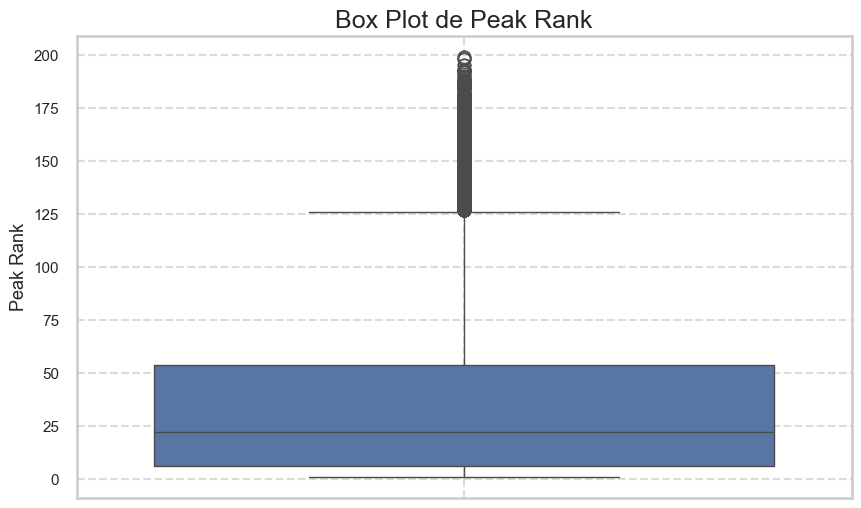

In [45]:
# Generar box plot para 'peak_rank'
print("Generando box plot para 'peak_rank'...")

# Convertir solo la columna necesaria a Pandas
if M_prop.count() > 200000:
    peak_rank_data = M_prop.select("peak_rank").sample(False, 0.1, seed=42).toPandas()
else:
    peak_rank_data = M_prop.select("peak_rank").toPandas()

plt.figure(figsize=(10, 6))
sns.boxplot(y=peak_rank_data['peak_rank'])
plt.title('Box Plot de Peak Rank')
plt.ylabel('Peak Rank')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [46]:
# Identificación y tratamiento de valores atípicos (outliers) para 'peak_rank'
# Calcular cuartiles para 'peak_rank'
cuantiles_peak_rank = M_prop.approxQuantile("peak_rank", [0.25, 0.75], 0.01)
q1_peak_rank, q3_peak_rank = cuantiles_peak_rank[0], cuantiles_peak_rank[1]
iqr_peak_rank = q3_peak_rank - q1_peak_rank

lower_bound_peak_rank = q1_peak_rank - 1.5 * iqr_peak_rank
upper_bound_peak_rank = q3_peak_rank + 1.5 * iqr_peak_rank

print(f"Q1 para peak_rank: {q1_peak_rank}")
print(f"Q3 para peak_rank: {q3_peak_rank}")
print(f"IQR para peak_rank: {iqr_peak_rank}")
print(f"Límite inferior para outliers en peak_rank: {lower_bound_peak_rank}")
print(f"Límite superior para outliers en peak_rank: {upper_bound_peak_rank}")

# Filtrar filas que estén dentro de los límites
M_prop_clean_peak_rank = M_prop.filter((F.col("peak_rank") >= lower_bound_peak_rank) & (F.col("peak_rank") <= upper_bound_peak_rank))

print(f"Registros originales en M_prop: {M_prop.count()}")
print(f"Registros después de eliminar outliers en peak_rank: {M_prop_clean_peak_rank.count()}")

# Actualizar M_prop para usar el DataFrame limpio
M_prop = M_prop_clean_peak_rank

Q1 para peak_rank: 6.0
Q3 para peak_rank: 53.0
IQR para peak_rank: 47.0
Límite inferior para outliers en peak_rank: -64.5
Límite superior para outliers en peak_rank: 123.5
Registros originales en M_prop: 482842
Registros después de eliminar outliers en peak_rank: 464436


In [47]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml import Pipeline
from pyspark.sql import functions as F

# Defina todas las columnas categóricas a procesar.
categorical_cols = ["pais", "entry_status", "Seniority", "Scope", "Tier"]
# Define all numerical columns to scale
numerical_cols = ["rank", "peak_rank", "previous_rank", "days_on_chart", "consecutive_days", "entry_rank"]

# 1. StringIndexers para columnas categóricas
indexers = [
    StringIndexer(inputCol=col, outputCol=col + "_indexed", handleInvalid="keep")
    for col in categorical_cols
]

# 2. Codificadores OneHot para columnas categóricas indexadas
encoders = [
    OneHotEncoder(inputCol=col + "_indexed", outputCol=col + "_encoded")
    for col in categorical_cols
]

# 3. VectorAssembler para características numéricas
numerical_assembler = VectorAssembler(inputCols=numerical_cols, outputCol="raw_numeric_features")

# 4. StandardScaler para características numéricas
scaler = StandardScaler(inputCol="raw_numeric_features", outputCol="scaled_numeric_features", withMean=True, withStd=True)

# 5. VectorAssemblerfinal para combinar características numéricas escaladas y características categóricas codificadas en formato one-hot.
final_feature_cols = [col + "_encoded" for col in categorical_cols] + ["scaled_numeric_features"]
final_assembler = VectorAssembler(inputCols=final_feature_cols, outputCol="features")

# Crea una canalizaciónpipeline para aplicar todas las transformaciones en orden.
pipeline = Pipeline(stages=indexers + encoders + [numerical_assembler, scaler, final_assembler])

# Compruebe si M_prop está vacío antes de procesar.
print(f"Registros en M_prop antes del pipeline: {M_prop.count()}")

# Ajusta el pipeline al DataFrame M_prop y transfórmarlo
M_prop_transformed = pipeline.fit(M_prop).transform(M_prop)

# Muestre el esquema del DataFrame transformado
print("Esquema de M_prop después de codificación categórica, escalado y ensamble de features:")
M_prop_transformed.printSchema()

print("Muestra de M_prop_transformed con nuevas columnas de índice, codificadas, escaladas y features finales:")
M_prop_transformed.select(
    [col + "_indexed" for col in categorical_cols] +
    [col + "_encoded" for col in categorical_cols] +
    numerical_cols + # Original numerical columns
    ["raw_numeric_features", "scaled_numeric_features", "features"]
).show(5, truncate=False)

# Actualiza M_prop_encoded para reflejar el DataFrame completamente transformado para los sigeintes pasos.
M_prop_encoded = M_prop_transformed

Registros en M_prop antes del pipeline: 464436
Esquema de M_prop después de codificación categórica, escalado y ensamble de features:
root
 |-- fecha: date (nullable = true)
 |-- artist_name: string (nullable = true)
 |-- pais: string (nullable = true)
 |-- rank: integer (nullable = true)
 |-- artist_uri: string (nullable = true)
 |-- peak_rank: integer (nullable = true)
 |-- previous_rank: integer (nullable = true)
 |-- days_on_chart: integer (nullable = true)
 |-- consecutive_days: integer (nullable = true)
 |-- entry_status: string (nullable = true)
 |-- entry_rank: integer (nullable = true)
 |-- entry_date: date (nullable = true)
 |-- Scope: string (nullable = false)
 |-- Tier: string (nullable = false)
 |-- Seniority: string (nullable = false)
 |-- pais_indexed: double (nullable = false)
 |-- entry_status_indexed: double (nullable = false)
 |-- Seniority_indexed: double (nullable = false)
 |-- Scope_indexed: double (nullable = false)
 |-- Tier_indexed: double (nullable = false)
 |

In [48]:
### Preparación Final del DataFrame para Modelado

In [49]:
from pyspark.sql import functions as F

# Seleccionar las columnas útiles: 'features' para el modelo y las etiquetas indexadas
M_preprocesado_final = M_prop_encoded.select(
    "features",
    F.col("Tier_indexed").alias("Tier_idx"),
    F.col("Seniority_indexed").alias("Seniority_idx"),
    F.col("Scope_indexed").alias("Scope_idx")
)

print("Esquema del DataFrame final para modelado:")
M_preprocesado_final.printSchema()

print("Muestra del DataFrame final:")
M_preprocesado_final.show(5, truncate=False)

Esquema del DataFrame final para modelado:
root
 |-- features: vector (nullable = true)
 |-- Tier_idx: double (nullable = false)
 |-- Seniority_idx: double (nullable = false)
 |-- Scope_idx: double (nullable = false)

Muestra del DataFrame final:
+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+--------+-------------+---------+
|features                                                                                                                                                                              |Tier_idx|Seniority_idx|Scope_idx|
+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+--------+-------------+---------+
|(85,[34,71,73,75,78,79,80,81,82,83,84],[1.0,1.0,1.0,1.0,1.0,-0.8809570152155448,-0.174033722851533

# Preparacion del conjunto de datos Training y Test

In [50]:
from pyspark.sql.functions import col
from functools import reduce

# Definir las columnas de estratificación
stratification_cols = ["Seniority_idx", "Scope_idx", "Tier_idx"]

# Obtener todas las combinaciones únicas de los estratos
distinct_strata = M_preprocesado_final.select(*stratification_cols).distinct().collect()

# Inicializar DataFrames vacíos para entrenamiento y prueba estratificados
stratified_train_dfs = []
stratified_test_dfs = []

# Proporción de división
train_ratio = 0.7 # Cambiado a 70%
test_ratio = 0.3  # Cambiado a 30%
seed = 42 # Para asegurar la reproducibilidad

print("Realizando muestreo estratificado...")

for row in distinct_strata:
    # Crear la condición de filtro para el estrato actual
    filter_condition = reduce(
        lambda a, b: a & b,
        [col(c) == row[c] for c in stratification_cols]
    )

    # Filtrar el DataFrame original por el estrato
    stratum_df = M_preprocesado_final.filter(filter_condition)

    # Dividir el estrato en entrenamiento y prueba
    (stratum_train, stratum_test) = stratum_df.randomSplit([train_ratio, test_ratio], seed=seed)

    stratified_train_dfs.append(stratum_train)
    stratified_test_dfs.append(stratum_test)

# Unir todos los DataFrames de entrenamiento y prueba estratificados
train_df_stratified = reduce(lambda df1, df2: df1.unionAll(df2), stratified_train_dfs)
test_df_stratified = reduce(lambda df1, df2: df1.unionAll(df2), stratified_test_dfs)

print("Muestreo estratificado completado.")
print(f"\nTamaño del conjunto de entrenamiento estratificado: {train_df_stratified.count()} registros")
print(f"Tamaño del conjunto de prueba estratificado: {test_df_stratified.count()} registros")

print("\nEsquema del conjunto de entrenamiento estratificado:")
train_df_stratified.printSchema()

print("\nMuestra del conjunto de entrenamiento estratificado:")
train_df_stratified.show(5, truncate=False)

print("\nMuestra del conjunto de prueba estratificado:")
test_df_stratified.show(5, truncate=False)

Realizando muestreo estratificado...
Muestreo estratificado completado.

Tamaño del conjunto de entrenamiento estratificado: 325468 registros
Tamaño del conjunto de prueba estratificado: 139410 registros

Esquema del conjunto de entrenamiento estratificado:
root
 |-- features: vector (nullable = true)
 |-- Tier_idx: double (nullable = false)
 |-- Seniority_idx: double (nullable = false)
 |-- Scope_idx: double (nullable = false)


Muestra del conjunto de entrenamiento estratificado:
+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+--------+-------------+---------+
|features                                                                                                                                                                             |Tier_idx|Seniority_idx|Scope_idx|
+------------------------------------------------------------------------------

In [51]:
print("Proporciones de 'Tier_idx' en M_preprocesado_final:")
M_preprocesado_final.groupBy("Tier_idx").count().withColumn("percentage", (col("count") / M_preprocesado_final.count()) * 100).orderBy("Tier_idx").show()

print("Proporciones de 'Tier_idx' en train_df_stratified:")
train_df_stratified.groupBy("Tier_idx").count().withColumn("percentage", (col("count") / train_df_stratified.count()) * 100).orderBy("Tier_idx").show()

print("Proporciones de 'Tier_idx' en test_df_stratified:")
test_df_stratified.groupBy("Tier_idx").count().withColumn("percentage", (col("count") / test_df_stratified.count()) * 100).orderBy("Tier_idx").show()

Proporciones de 'Tier_idx' en M_preprocesado_final:
+--------+------+------------------+
|Tier_idx| count|        percentage|
+--------+------+------------------+
|     0.0|336648| 72.48533705397514|
|     1.0|127788|27.514662946024853|
+--------+------+------------------+

Proporciones de 'Tier_idx' en train_df_stratified:
+--------+------+-----------------+
|Tier_idx| count|       percentage|
+--------+------+-----------------+
|     0.0|235699|72.41848661005076|
|     1.0| 89769|27.58151338994924|
+--------+------+-----------------+

Proporciones de 'Tier_idx' en test_df_stratified:
+--------+------+------------------+
|Tier_idx| count|        percentage|
+--------+------+------------------+
|     0.0|101423| 72.75159601176387|
|     1.0| 37987|27.248403988236134|
+--------+------+------------------+



In [52]:
from pyspark.sql.functions import col

stratification_cols = ["Seniority_idx", "Scope_idx", "Tier_idx"]

def check_stratification_balance(df, df_name, cols):
    print(f"\n--- Distribución de estratos en {df_name} ---")
    for c in cols:
        print(f"Distribución de '{c}':")
        df.groupBy(c).count().withColumn("percentage", (col("count") / df.count()) * 100).orderBy(c).show()

    # También verificar la distribución de la combinación de estratos
    print("Distribución de la combinación de estratos (Seniority_idx, Scope_idx, Tier_idx):")
    df.groupBy(*cols).count().withColumn("percentage", (col("count") / df.count()) * 100).orderBy(*cols).show(truncate=False)

# Verificar el DataFrame original
check_stratification_balance(M_preprocesado_final, "M_preprocesado_final (Original)", stratification_cols)

# Verificar el conjunto de entrenamiento estratificado
check_stratification_balance(train_df_stratified, "train_df_stratified", stratification_cols)

# Verificar el conjunto de prueba estratificado
check_stratification_balance(test_df_stratified, "test_df_stratified", stratification_cols)


--- Distribución de estratos en M_preprocesado_final (Original) ---
Distribución de 'Seniority_idx':
+-------------+------+------------------+
|Seniority_idx| count|        percentage|
+-------------+------+------------------+
|          0.0|365534| 78.70492382158145|
|          1.0| 98902|21.295076178418554|
+-------------+------+------------------+

Distribución de 'Scope_idx':
+---------+------+-----------------+
|Scope_idx| count|       percentage|
+---------+------+-----------------+
|      0.0|236568|50.93661990026613|
|      1.0|227868|49.06338009973387|
+---------+------+-----------------+

Distribución de 'Tier_idx':
+--------+------+------------------+
|Tier_idx| count|        percentage|
+--------+------+------------------+
|     0.0|336648| 72.48533705397514|
|     1.0|127788|27.514662946024853|
+--------+------+------------------+

Distribución de la combinación de estratos (Seniority_idx, Scope_idx, Tier_idx):
+-------------+---------+--------+------+------------------+


# Construcción de modelos de aprendizaje supervisado y no supervisado

In [61]:
#Define las rutas donde se guardarán los DataFrames
# Asegúrate de que estas rutas sean apropiadas para tu entorno de Spark (HDFS, S3, sistema de archivos local, etc.)
output_path_train = "./data/train_df_stratified.parquet"
output_path_test = "./data/test_df_stratified.parquet"

# Guardar el conjunto de entrenamiento
print(f"Guardando el conjunto de entrenamiento en: {output_path_train}")
train_df_stratified.write.mode("overwrite").parquet(output_path_train)

# Guardar el conjunto de prueba
print(f"Guardando el conjunto de prueba en: {output_path_test}")
test_df_stratified.write.mode("overwrite").parquet(output_path_test)

print("Conjuntos de entrenamiento y prueba guardados exitosamente.")

Guardando el conjunto de entrenamiento en: ./data/train_df_stratified.parquet


Py4JJavaError: An error occurred while calling o2219.parquet.
: java.lang.IllegalStateException: Cannot call methods on a stopped SparkContext.
This stopped SparkContext was created at:

org.apache.spark.api.java.JavaSparkContext.<init>(JavaSparkContext.scala:58)
java.base/jdk.internal.reflect.NativeConstructorAccessorImpl.newInstance0(Native Method)
java.base/jdk.internal.reflect.NativeConstructorAccessorImpl.newInstance(NativeConstructorAccessorImpl.java:62)
java.base/jdk.internal.reflect.DelegatingConstructorAccessorImpl.newInstance(DelegatingConstructorAccessorImpl.java:45)
java.base/java.lang.reflect.Constructor.newInstance(Constructor.java:490)
py4j.reflection.MethodInvoker.invoke(MethodInvoker.java:247)
py4j.reflection.ReflectionEngine.invoke(ReflectionEngine.java:374)
py4j.Gateway.invoke(Gateway.java:238)
py4j.commands.ConstructorCommand.invokeConstructor(ConstructorCommand.java:80)
py4j.commands.ConstructorCommand.execute(ConstructorCommand.java:69)
py4j.ClientServerConnection

In [70]:
# Construcción de modelos de aprendizaje supervisado y no supervisado

In [63]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator

# Definir la variable objetivo (label column) y las características (features column)
# En este caso, queremos predecir si un artista es 'Top' o 'LongTail' (Tier_idx)
label_col = "Tier_idx"
features_col = "features"

print(f"Construyendo modelo de RandomForestClassifier para predecir: {label_col}")

# Inicializar el modelo de RandomForestClassifier
# Se pueden ajustar parámetros como numTrees, maxDepth, etc., para optimización futura
rf = RandomForestClassifier(labelCol=label_col, featuresCol=features_col, seed=42)

# Entrenar el modelo con el conjunto de entrenamiento estratificado
print("Entrenando el modelo RandomForest...")
rf_model = rf.fit(train_df_stratified)
print("Modelo RandomForest entrenado exitosamente.")

# Realizar predicciones en el conjunto de prueba estratificado
print("Realizando predicciones en el conjunto de prueba...")
predictions = rf_model.transform(test_df_stratified)

# Evaluar el modelo con Accuracy
# Utilizaremos la métrica 'accuracy' para la evaluación básica
multiclass_evaluator = MulticlassClassificationEvaluator(
    labelCol=label_col, predictionCol="prediction", metricName="accuracy")

accuracy = multiclass_evaluator.evaluate(predictions)
print(f"\nPrecisión (Accuracy) del modelo en el conjunto de prueba: {accuracy:.4f}")

# Evaluar el modelo con AUC (Area Under ROC)
# Para clasificación binaria, AUC es una métrica muy importante.
binary_evaluator = BinaryClassificationEvaluator(
    labelCol=label_col, rawPredictionCol="rawPrediction", metricName="areaUnderROC")

auc = binary_evaluator.evaluate(predictions)
print(f"Área bajo la Curva ROC (AUC) del modelo en el conjunto de prueba: {auc:.4f}")

# También podemos ver un resumen de las predicciones
print("\nPredicciones (muestra):")
predictions.select(label_col, "prediction", "rawPrediction", "probability").show(5, truncate=False)

Construyendo modelo de RandomForestClassifier para predecir: Tier_idx
Entrenando el modelo RandomForest...


Py4JJavaError: An error occurred while calling o2259.fit.
: java.lang.IllegalStateException: Cannot call methods on a stopped SparkContext.
This stopped SparkContext was created at:

org.apache.spark.api.java.JavaSparkContext.<init>(JavaSparkContext.scala:58)
java.base/jdk.internal.reflect.NativeConstructorAccessorImpl.newInstance0(Native Method)
java.base/jdk.internal.reflect.NativeConstructorAccessorImpl.newInstance(NativeConstructorAccessorImpl.java:62)
java.base/jdk.internal.reflect.DelegatingConstructorAccessorImpl.newInstance(DelegatingConstructorAccessorImpl.java:45)
java.base/java.lang.reflect.Constructor.newInstance(Constructor.java:490)
py4j.reflection.MethodInvoker.invoke(MethodInvoker.java:247)
py4j.reflection.ReflectionEngine.invoke(ReflectionEngine.java:374)
py4j.Gateway.invoke(Gateway.java:238)
py4j.commands.ConstructorCommand.invokeConstructor(ConstructorCommand.java:80)
py4j.commands.ConstructorCommand.execute(ConstructorCommand.java:69)
py4j.ClientServerConnection.wai

In [ ]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

# Definir la columna de características para el clustering
features_col = "features"

# Elegir el número de clusters (K). Podemos empezar con un número arbitrario y luego optimizar.
# Basándonos en la estructura de los perfiles (8 combinaciones), un K inicial podría ser 4 o 8
# para ver si se agrupan de forma significativa. Usemos 4 para empezar.
k_clusters = 4

print(f"Construyendo modelo K-Means con K = {k_clusters} clusters.")

# Inicializar el modelo K-Means
kmeans = KMeans(featuresCol=features_col, k=k_clusters, seed=42)

# Entrenar el modelo con el DataFrame preprocesado completo (M_preprocesado_final)
print("Entrenando el modelo K-Means...")
kmeans_model = kmeans.fit(M_preprocesado_final)
print("Modelo K-Means entrenado exitosamente.")

# Realizar predicciones de cluster para cada punto de datos
print("Asignando clusters a los datos...")
clustered_data = kmeans_model.transform(M_preprocesado_final)

# Evaluar el modelo de clustering usando WSSSE (Within Set Sum of Squared Errors)
WSSSE = kmeans_model.summary.trainingCost
print(f"\nWithin Set Sum of Squared Errors (WSSSE): {WSSSE:.2f}")

# También podemos usar Silhouette Score para evaluar la calidad del clustering
# El Silhouette Score mide la similitud de un objeto con su propio cluster (cohesión)
# en comparación con otros clusters (separación).
# Un valor cercano a 1 indica que el objeto está bien emparejado con su propio cluster
# y mal emparejado con clusters vecinos. Un valor cercano a -1 indica lo contrario.
# Un valor cercano a 0 indica solapamiento entre clusters.

evaluator = ClusteringEvaluator(featuresCol=features_col,
                                metricName="silhouette", distanceMeasure="cosine")

silhouette = evaluator.evaluate(clustered_data)
print(f"Silhouette Score: {silhouette:.4f}")

print("\nClusters asignados (muestra):")
clustered_data.select(features_col, "prediction").show(5, truncate=False)

# Opcional: Ver el tamaño de cada cluster
print("\nTamaño de cada cluster:")
clustered_data.groupBy("prediction").count().orderBy("prediction").show()